# Monthly RMS

In [2]:
import xarray as xr
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.patches as mpatches
from tqdm import tqdm

In [ ]:
rms = xr.open_mfdataset('RMS_dweighted/RMS_*.nc')
rms = rms.compute()
rms

In [ ]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

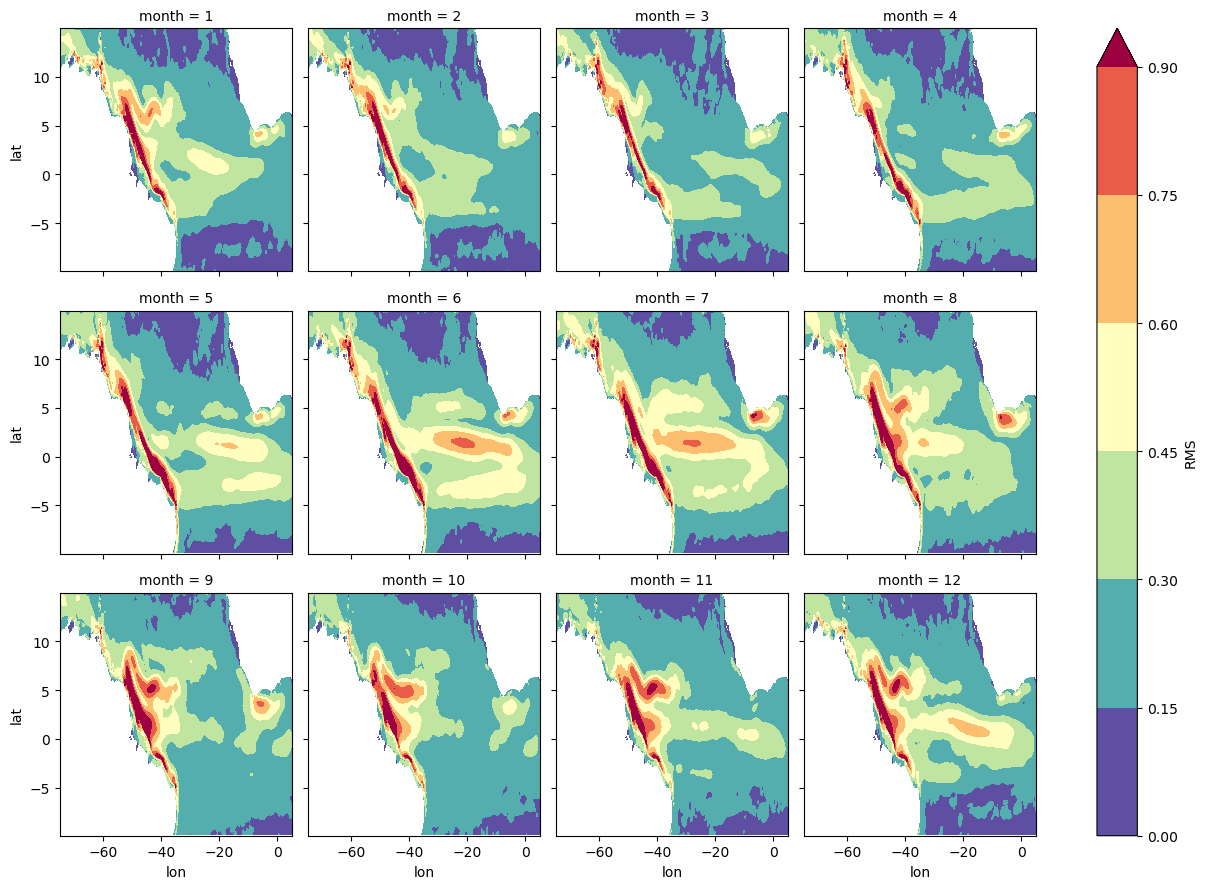

In [19]:
seasonality(rms).sel(lon=slice(-75,5),lat=slice(-10,15)).RMS.plot.contourf(
    x="lon", y="lat", col="month", col_wrap=4,robust=True,cmap='Spectral_r')

In [25]:
months = rms.time.dt.month

month_to_season = {
    10: 'OND', 11: 'OND', 12: 'OND',
    1: 'JFM', 2: 'JFM', 3: 'JFM',
    4: 'AMJ', 5: 'AMJ', 6: 'AMJ',
    7: 'JAS', 8: 'JAS', 9: 'JAS',
}

# Map to season labels
season_labels = xr.apply_ufunc(
    np.vectorize(month_to_season.get),
    months,
    dask='parallelized',
    output_dtypes=[object]
)

# Groupby season and compute (e.g. mean)
rms_seasonal = rms.groupby(season_labels).mean('time')
rms_seasonal

<xarray.Dataset> Size: 10MB
Dimensions:  (month: 4, lat: 499, lon: 1260)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * month    (month) object 32B 'AMJ' 'JAS' 'JFM' 'OND'
Data variables:
    RMS      (month, lat, lon) float32 10MB nan nan nan nan ... nan nan nan nan

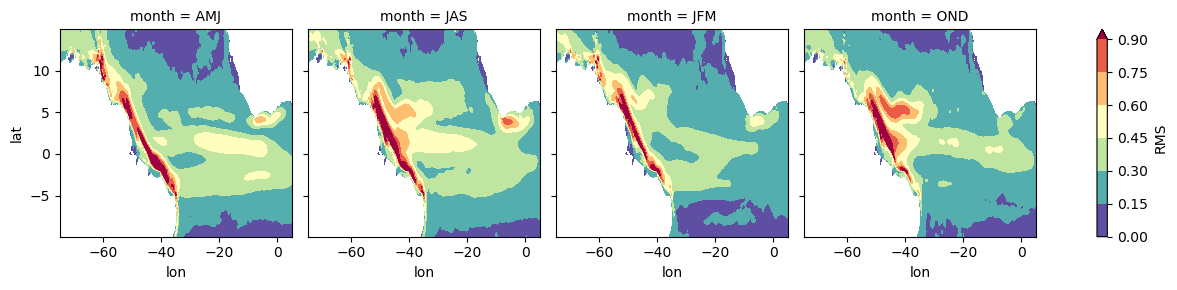

In [28]:
rms_seasonal.sel(lon=slice(-75,5),lat=slice(-10,15)).RMS.plot.contourf(
    x="lon", y="lat", col="month", col_wrap=4,robust=True,cmap='Spectral_r')